In [117]:
import numpy as np

## **Tokenizer**

In [118]:
X = [
    [1,  2,  3,  4],
    [5,  6,  7,  8],
    [9, 10, 11, 12],
    [13, 14, 15, 16]
]

Creating the shape, transpose and the multiplication function

In [119]:
# Level 0 and 1 

def matrix_shape(A):
    count = len(A[0])
    return (len(A), count)


def transpose(A):
    return [[A[i][j] for i in range(len(A))] for j in range(len(A[0]))]

def matrix_multiply(A, B):
    if matrix_shape(A)[1] != matrix_shape(B)[0]:
        return 'Matrix Multiplication is not possible.'
    else:
        B_t = transpose(B)
        result = []
        for row_a in A:
            new_row = []
            for row_b_t in B_t:
                element = sum(a * b for a, b in zip(row_a, row_b_t))
                new_row.append(element)
        
            result.append(new_row)

        return result


# Define Regions

def extract_region(X, row_start:int, col_start:int, size:int):
    element = [[X[row_start+i][col_start+j] for j in range(size)] for i in range(size)]
    return element



# Create single patch

def extract_patch(X, patch_row: int, patch_col: int, patch_size: int):
    start_row = patch_row * patch_size
    end_row = start_row + patch_size

    start_col = patch_col * patch_size
    end_col = start_col + patch_size

    return [row[start_col:end_col] for row in X[start_row:end_row]]

print('Done ✅')

Done ✅


In [120]:
# Level 2


# Number of Patches
def number_of_patches(X, P:int)->int:
    H = matrix_shape(X)[0]
    W = matrix_shape(X)[1]

    Nh = H // P
    Nw = W // P

    return Nh * Nw

# Extracting multiple patches

def extract_patches(X, P: int):
    H = len(X)
    W = len(X[0])
    
    Nh = H // P
    Nw = W // P

    N = Nh * Nw
    
    patches = []
    for p in range(N):
        patch = extract_patch(X, p // Nw, p % Nw, P)
        patches.append(patch)
        
    return patches

print('Done ✅')

Done ✅


In [121]:
# Level 3 flattened patch/patches for image pixel matrix

def flatten_patch(patch):
    x = [element for row in patch for element in row]
    return x

def flatten_patches(patches):
    '''
    This always returns N x P^2 flattened patches.
    '''
    N = len(patches)
    flattened_patches = []
    for p in range(N):
        flattened_patches.append(flatten_patch(patches[p]))
    return flattened_patches

print('Done ✅')

Done ✅


In [122]:
# Level 4 porjection patch matrix creation

def create_matrix(r, c, value):
    return [[value for j in range(c)] for i in range(r)]

import random

def random_matrix(r, c, seed=None):
    random.seed(seed)
    return [[random.random() for j in range(c)] for i in range(r)]


X_patches = flatten_patches(extract_patches(X, 2))
N = matrix_shape(X_patches)[0]
P_squared = matrix_shape(X_patches)[1]
D = 4
W_E = random_matrix(P_squared, D, 42)

def project_patches(X_patches, W_E):
    return matrix_multiply(X_patches, W_E)


T = project_patches(X_patches, W_E)
b = [0 for _ in range(D)]

def add_bias(T, b):
    result = []
    for row in T:
        new_row = [row[j] + b[j] for j in range(len(row))]
        result.append(new_row)

    return result

C = add_bias(T, b)
print(C[:2])
print('Done ✅')

[[4.381194143315443, 2.720421731378732, 7.051884954473966, 6.193513727543767], [8.029905747297503, 4.581111956919326, 11.123347551788148, 8.914406406513404]]
Done ✅


In [123]:
# Level 5 Embedding matrix

'''
    Position Embedding Matrix
'''

'''def create_position_matrix(N, D):

    matrix = []
    for i in range(N):
        row = []
        for j in range(D):
            row.append(i + j) # using i + j is not an optimal method for position matrix
        matrix.append(row)
    return matrix'''
import math
def create_position_matrix(N, D):
    sinusoid = []
    for j in range(N):
        row = []
        for i in range(D):
            k = i // 2
            if i%2 == 0:
                element = math.sin(j / 10000**((2*k) / D))
            else:
                element = math.cos(j / 10000**((2*k) / D))
            row.append(element)
        sinusoid.append(row)
    return sinusoid
    
def add_position_embeddings(T, E_pos):
    '''
    Adding Embedding Matrix
    '''
    result = []
    for i in range(len(T)):
        row = []
        for j in range(len(T[0])):
            row.append(T[i][j] + E_pos[i][j])
        result.append(row)
    return result

E_pos = create_position_matrix(N, D)

Z = add_position_embeddings(C, E_pos)

print(Z[:2])
print('Done ✅')

[[4.381194143315443, 3.720421731378732, 7.051884954473966, 7.193513727543767], [8.8713767321054, 5.121414262787466, 11.133347385122315, 9.91435640693007]]
Done ✅


In [124]:
# Level 6

def tokenize_image(X, P, D):
    X_patches = extract_patches(X, P = P)
    X_flatten = flatten_patches(X_patches)

    P_squared = P ** 2

    W_E = random_matrix(P_squared, D, seed = 42)

    T = project_patches(X_flatten, W_E)
    
    b = [0 for _ in range(D)]

    N = matrix_shape(X_flatten)[0]

    C = add_bias(T, b)

    E_pos = create_position_matrix(N, D)

    Z = add_position_embeddings(C, E_pos)

    return Z

tokenized_image = tokenize_image(X, 2, 4)

print(tokenized_image[:2])
print(f'Dimensions of the tokenized image: {matrix_shape(tokenized_image)}')

[[4.381194143315443, 3.720421731378732, 7.051884954473966, 7.193513727543767], [8.8713767321054, 5.121414262787466, 11.133347385122315, 9.91435640693007]]
Dimensions of the tokenized image: (4, 4)


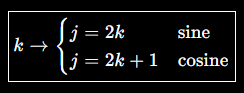

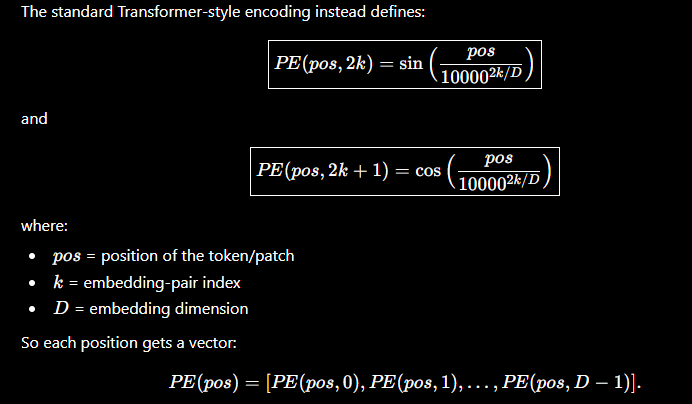

In [125]:
# Level 7 Sinusoidal Position Matrix
import math
print(math.sin(math.pi/2))
def create_sinusoidal_position_matrix(N, D):
    sinusoid = []
    for j in range(N):
        row = []
        for i in range(D):
            k = i // 2
            if i%2 == 0:
                element = math.sin(j / 10000**((2*k) / D))
            else:
                element = math.cos(j / 10000**((2*k) / D))
            row.append(element)
        sinusoid.append(row)
    return sinusoid

print(matrix_shape(create_sinusoidal_position_matrix(3, 4)))
PE = create_sinusoidal_position_matrix(3, 4)
PE



1.0
(3, 4)


[[0.0, 1.0, 0.0, 1.0],
 [0.8414709848078965,
  0.5403023058681398,
  0.009999833334166664,
  0.9999500004166653],
 [0.9092974268256817,
  -0.4161468365471424,
  0.01999866669333308,
  0.9998000066665778]]

In [126]:
# After implementation of sinusoidal position matrix

Z = tokenize_image(X, P=4, D=16)

print(f'Matrix shape of the image matrix {matrix_shape(X)} output: is {matrix_shape(Z)}')

Z

Matrix shape of the image matrix (4, 4) output: is (1, 16)


[[53.9938923123651,
  82.78759848616433,
  64.40425769802242,
  95.5725819124271,
  59.61830969261926,
  74.43645230103253,
  79.99799140578683,
  71.65638006931886,
  70.27202720936403,
  69.99168685246975,
  63.20677218801313,
  49.92572725442129,
  67.95539978324679,
  66.52037373130634,
  69.11631445771972,
  71.32945428403947]]

In [127]:
# Level 8.1 Image Tokenization Test for different spatial positions

image = [[i * 8 + j + 1 for j in range(8)] for i in range(8)]

tokenized_image = tokenize_image(image, P=2, D=4)

print(f'Matrix shape of the image matrix {matrix_shape(image)} output: is {matrix_shape(tokenized_image)}')

for i in range(len(tokenized_image)):
    print(tokenized_image[i])

Matrix shape of the image matrix (8, 8) output: is (16, 4)
[6.175025300791979, 4.634961211877608, 10.525974604806471, 11.394700802370084]
[10.665207889581936, 6.035953743286342, 14.607437035454822, 14.115543481756385]
[14.38174593558178, 6.940194826411654, 18.68889846612817, 16.836286166975935]
[17.262280120798028, 8.227039391898945, 22.770357896951516, 19.556928873027978]
[34.60791563734053, 17.86683939533875, 43.13766471750657, 33.16104234078815]
[38.05450546196738, 20.664835427206178, 47.2191171499048, 35.88148517349177]
[42.38272584241366, 23.202033753933918, 51.30056458442775, 38.60182813200164]
[46.96783954331343, 24.85645594716745, 55.38200602260002, 41.32207127128936]
[65.54376921112832, 33.2605047867185, 75.74929085580257, 54.92578537218688]
[68.61524105372877, 34.35556478418303, 79.83071730834558, 57.64582907786589]
[71.3078130615797, 36.288313742531855, 83.91213477310859, 60.36577318910155]
[74.50055556990043, 38.992501195136946, 87.99354225461312, 63.085617800749866]
[93.20

In [128]:
image_3d = [[[i * 8 + j, 1, 2] for j in range(32)] for i in range(32)]

In [129]:
# Level 9 Added RGB flattening, divisibility, and normalization


import math
import random


def tokenize_image(
    X,
    P,
    D,
    use_rgb: bool = False,
    normalization: bool = False,
    seed: int = 42,
):
    def matrix_shape(A):
        return (len(A), len(A[0]))

    def transpose(A):
        return [[A[i][j] for i in range(len(A))] for j in range(len(A[0]))]

    def matrix_multiply(A, B):
        if matrix_shape(A)[1] != matrix_shape(B)[0]:
            raise ValueError("Matrix Multiplication is not possible.")
        else:
            B_t = transpose(B)
            result = []
            for row_a in A:
                new_row = []
                for row_b_t in B_t:
                    element = sum(a * b for a, b in zip(row_a, row_b_t))
                    new_row.append(element)
                result.append(new_row)
            return result

    def extract_patch(X, patch_row: int, patch_col: int, patch_size: int):
        start_row = patch_row * patch_size
        end_row = start_row + patch_size
        start_col = patch_col * patch_size
        end_col = start_col + patch_size
        return [row[start_col:end_col] for row in X[start_row:end_row]]

    def extract_patches(X, P: int):
        H = len(X)
        W = len(X[0])
        Nh = H // P
        Nw = W // P
        N = Nh * Nw
        patches = []
        for p in range(N):
            patch = extract_patch(X, p // Nw, p % Nw, P)
            patches.append(patch)
        return patches

    def flatten_patch(patch):
        return [element for row in patch for element in row]

    def flatten_patches(patches):
        N = len(patches)
        flattened_patches = []
        for p in range(N):
            flattened_patches.append(flatten_patch(patches[p]))
        return flattened_patches

    def random_matrix(r, c, seed=None):
        random.seed(seed)
        return [[random.random() for j in range(c)] for i in range(r)]

    def project_patches(X_patches, W_E):
        return matrix_multiply(X_patches, W_E)

    def add_bias(T, b):
        result = []
        for row in T:
            new_row = [row[j] + b[j] for j in range(len(row))]
            result.append(new_row)
        return result
    '''
    Using the sin and cos for the positional element : sinusoidal
    '''
    def create_position_matrix(N, D):
        sinusoid = []
        for j in range(N):
            row = []
            for i in range(D):
                k = i // 2
                if i % 2 == 0:
                    element = math.sin(j / 10000 ** ((2 * k) / D))
                else:
                    element = math.cos(j / 10000 ** ((2 * k) / D))
                row.append(element)
            sinusoid.append(row)
        return sinusoid

    def add_position_embeddings(T, E_pos):
        result = []
        for i in range(len(T)):
            row = []
            for j in range(len(T[0])):
                row.append(T[i][j] + E_pos[i][j])
            result.append(row)
        return result

    def validate_divisibility(image, P: int):
        H = len(image)
        W = len(image[0])
        if H % P != 0 or W % P != 0:
            raise ValueError(
                f"Image dimensions ({H}, {W}) are not divisible by patch size {P}."
            )

    def flatten_rgb_patches(image, P: int):
        H = len(image)
        W = len(image[0])
        C = len(image[0][0])
        patches_flat = []
        coords = []
        n_rows = H // P
        n_cols = W // P
        for r in range(n_rows):
            for c in range(n_cols):
                row_start = r * P
                col_start = c * P
                flat_patch = []
                for i in range(row_start, row_start + P):
                    for j in range(col_start, col_start + P):
                        for k in range(C):
                            flat_patch.append(image[i][j][k])
                patches_flat.append(flat_patch)
                coords.append((r, c))
        return patches_flat, coords

    def normalize(Z):
        norm_Z = []
        dim = len(Z[0])
        eps = 1e-5
        for row in Z:
            mean = sum(row) / dim
            var = sum((x - mean) ** 2 for x in row) / dim
            std = (var + eps) ** 0.5 # adding an episilon to the variance since the variance of population is usually unknown
            norm_Z.append([(x - mean) / std for x in row])
        return norm_Z

    validate_divisibility(X, P)

    if use_rgb:
        X_flatten, coords = flatten_rgb_patches(X, P)
        print("=" * 20, "Flatten RGB Patches", "=" * 20)
        print(X_flatten)
        print(f"Coordinates of the faltten RGB is: {coords}")
    else:
        X_patches = extract_patches(X, P=P)
        X_flatten = flatten_patches(X_patches)

    patch_dim = len(X_flatten[0])

    W_E = random_matrix(patch_dim, D, seed=seed)

    T = project_patches(X_flatten, W_E)

    b = [0 for _ in range(D)]

    N = matrix_shape(X_flatten)[0]

    C = add_bias(T, b)

    E_pos = create_position_matrix(N, D)

    Z = add_position_embeddings(C, E_pos)

    if normalization == True:
        Z = normalize(Z)
        print('📈 Normalized values as output')
    print('✅ Successful')
    return Z

In [135]:
tokenized_3d_image = tokenize_image(X = image_3d, P = 2, D = 4, use_rgb = True, normalization = True, seed = 24)
print('='*60)
print('First Preview of the normalized token of 32x32 image:')
for row in tokenized_3d_image[:2]:
    print(row)

print('='*60)
print(f'Matrix Shape of the tokenized 3D image: {matrix_shape(tokenized_3d_image)}')

==================== Flatten RGB Patches ====================
[[0, 1, 2, 1, 1, 2, 8, 1, 2, 9, 1, 2], [2, 1, 2, 3, 1, 2, 10, 1, 2, 11, 1, 2], [4, 1, 2, 5, 1, 2, 12, 1, 2, 13, 1, 2], [6, 1, 2, 7, 1, 2, 14, 1, 2, 15, 1, 2], [8, 1, 2, 9, 1, 2, 16, 1, 2, 17, 1, 2], [10, 1, 2, 11, 1, 2, 18, 1, 2, 19, 1, 2], [12, 1, 2, 13, 1, 2, 20, 1, 2, 21, 1, 2], [14, 1, 2, 15, 1, 2, 22, 1, 2, 23, 1, 2], [16, 1, 2, 17, 1, 2, 24, 1, 2, 25, 1, 2], [18, 1, 2, 19, 1, 2, 26, 1, 2, 27, 1, 2], [20, 1, 2, 21, 1, 2, 28, 1, 2, 29, 1, 2], [22, 1, 2, 23, 1, 2, 30, 1, 2, 31, 1, 2], [24, 1, 2, 25, 1, 2, 32, 1, 2, 33, 1, 2], [26, 1, 2, 27, 1, 2, 34, 1, 2, 35, 1, 2], [28, 1, 2, 29, 1, 2, 36, 1, 2, 37, 1, 2], [30, 1, 2, 31, 1, 2, 38, 1, 2, 39, 1, 2], [16, 1, 2, 17, 1, 2, 24, 1, 2, 25, 1, 2], [18, 1, 2, 19, 1, 2, 26, 1, 2, 27, 1, 2], [20, 1, 2, 21, 1, 2, 28, 1, 2, 29, 1, 2], [22, 1, 2, 23, 1, 2, 30, 1, 2, 31, 1, 2], [24, 1, 2, 25, 1, 2, 32, 1, 2, 33, 1, 2], [26, 1, 2, 27, 1, 2, 34, 1, 2, 35, 1, 2], [28, 1, 2, 29, 1, 2, 36, 